In [1]:
import torch
import torch.multiprocessing as mp
from gymnasium.vector import AsyncVectorEnv
import numpy as np
from env import mbb
from models import ppo
import os
import pandas as pd
import matplotlib.pyplot as plt
import logging
from datetime import datetime
import random
from torch import amp
from env import mbb_cnn
from models import ppo_cnn


In [2]:

# Configure logging
logging.basicConfig(
    level=logging.INFO,  # Set to DEBUG for more detailed logs
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("reward_logs.log"),  # Log to a file
        logging.StreamHandler()  # Also log to console
    ]
)


print("============================================================================================")
device = torch.device('cpu')
if(torch.cuda.is_available()): 
    device = torch.device('cuda:0') 
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")  
print("============================================================================================")


Device set to : NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
# ============================================================================
# CONFIGURATION: Choose training mode
# ============================================================================
USE_RANDOM_BEAMS = True      # True = domain randomization (infinite beam variety)
USE_TWO_PATH_ARCH = True     # True = force encoder architecture (separate BC path)

# Fixed beam types for evaluation (always test on these for comparison)
EVAL_BEAM_TYPES = [1, 2, 3, 4, 5, 6, 7, 8, 9]  # Test on all beam types

def make_random_beam_env():
    """Create environment with randomly generated beam configuration."""
    return mbb_cnn.BeamOptimizationEnv(
        width=6, height=6, density=0.4, optimal_density=0.5, 
        reward_weights=None, use_random_beam=True
    )

def make_fixed_beam_env(beam_type):
    """Create environment with a specific beam type."""
    return mbb_cnn.BeamOptimizationEnv(
        width=6, height=6, density=0.4, optimal_density=0.5, 
        reward_weights=None, beam_type=beam_type
    )

# Choose which environment factory to use
if USE_RANDOM_BEAMS:
    print("🎲 Training with DOMAIN RANDOMIZATION (random beam configs each episode)")
    make_beam_env = make_random_beam_env
else:
    print("📌 Training with FIXED beam types: [1, 2, 3, 5, 6, 8]")
    TRAIN_BEAM_TYPES = [1, 2, 3, 5, 6, 8]
    def make_beam_env():
        beam_type = random.choice(TRAIN_BEAM_TYPES)
        return mbb_cnn.BeamOptimizationEnv(
            width=6, height=6, density=0.4, optimal_density=0.5, 
            reward_weights=None, beam_type=beam_type
        )

if __name__ == "__main__":
    mp.set_start_method('spawn', force=True)

    # Set random seeds for reproducibility
    random_seed = 0
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Hyperparameters
    env_name = "BeamOptimizationEnv"
    num_envs = 64
    width = 6
    height = 6
    channels = 5  # Densities, Normals X & Y, Forces X & Y
    action_dim = 2 * width * height  # Assuming discrete actions: increase or decrease each cell
    has_continuous_action_space = False
    max_ep_len = width * height * 3  # 108 steps per episode
    max_training_timesteps = int(1e4)  # Increased for 6 beam types (was 2e4 for 2 types)
    update_timestep = max_ep_len  # Update PPO every 'update_timestep' timesteps

    # Action std decay parameters (only for continuous action spaces)
    action_std_decay_freq = 5000
    action_std_decay_rate = 0.05
    min_action_std = 0.1

    # Define the environment functions for vectorized environments
    env_fns = [make_beam_env for _ in range(num_envs)]  # Pass the function itself

    # Create vectorized environments
    vector_env = AsyncVectorEnv(env_fns)
    print(f"Vector Environment Type: {type(vector_env)}")

    # Get state and action dimensions
    state_shape = vector_env.single_observation_space.shape  # Should be (channels, width+1, height+1)
    print(f"State shape: {state_shape}")

    state_channels = state_shape[0]
    state_width = state_shape[1]
    state_height = state_shape[2]

    if has_continuous_action_space:
        action_dim = vector_env.single_action_space.shape[0]
    else:
        action_dim = vector_env.single_action_space.n

    print(f"Action dimension: {action_dim}")

    # Initialize PPO agent
    ppo_agent = ppo_cnn.PPO(
        state_channels=state_channels,
        width=state_width,
        height=state_height,
        action_dim=action_dim,
        lr_actor=0.0003,
        lr_critic=0.001,
        gamma=0.95,
        K_epochs=4,
        eps_clip=0.2,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=0.6,
        gae_lambda=0.95,
        num_envs=num_envs,
        device=device,
        use_two_path=USE_TWO_PATH_ARCH  # Force encoder architecture
    )

    # Track total training time
    start_time = datetime.now().replace(microsecond=0)
    print("Started training at (GMT) :", start_time)
    print("============================================================================================")

    ###################### Logging ######################
    # Directory setup
    log_dir = "PPO_logs"
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)

    log_dir = os.path.join(log_dir, env_name)
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)

    # Determine run number based on existing log files
    run_num = len([name for name in os.listdir(log_dir) if os.path.isfile(os.path.join(log_dir, name))])
    log_f_name = os.path.join(log_dir, f'PPO_{env_name}_log_{run_num}.csv')

    print(f"Current logging run number for {env_name}: {run_num}")
    print(f"Logging at: {log_f_name}")

    #####################################################

    ################### Checkpointing ###################
    run_num_pretrained = 0  # Change this to prevent overwriting weights in the same env_name folder

    checkpoint_dir = "PPO_preTrained"
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    checkpoint_dir = os.path.join(checkpoint_dir, env_name)
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    checkpoint_path = os.path.join(checkpoint_dir, f"PPO_{env_name}_{random_seed}_{run_num_pretrained}.pth")
    print(f"Save checkpoint path: {checkpoint_path}")

    #####################################################

    # Initialize logging file
    with open(log_f_name, "w+") as log_f:
        log_f.write('episode,timestep,average_reward\n')

    print_running_reward = 0
    log_running_reward = 0
    print_running_episodes = 0
    log_running_episodes = 0

    # Initialize training variables
    timestep = 0
    i_episode = 0

    #################### Training Loop ####################
    while timestep < max_training_timesteps:
        # Reset all environments and unpack the observations and info
        states, infos = vector_env.reset()
        # Convert states to torch tensors
        states = torch.tensor(states, dtype=torch.float32).to(device)  # Shape: [num_envs, channels, W, H]
        ep_rewards = np.zeros(num_envs)
        done_flags = np.array([False] * num_envs)

        for t_step in range(1, max_ep_len + 1):
            # Select actions for all environments (returns GPU tensors)
            actions, logprobs, state_values = ppo_agent.select_action(states)

            # Take actions in all environments - MUST convert to numpy/CPU for async workers
            try:
                actions_np = actions.cpu().numpy()  # Convert to numpy for environment
                next_states, rewards, dones, truncateds, infos = vector_env.step(actions_np)
            except Exception as e:
                print(f"Error during environment step: {e}")
                break

            # Combine done flags
            dones_combined = np.logical_or(dones, truncateds)

            # Convert next_states to torch tensors
            next_states = torch.tensor(next_states, dtype=torch.float32).to(device)

            # Store transitions in the buffer (actions already a tensor from select_action)
            ppo_agent.buffer.store(
                states=states,  # [num_envs, channels, W, H]
                actions=actions,  # [num_envs] - already a tensor from select_action
                logprobs=logprobs,  # [num_envs] - already a tensor
                rewards=torch.tensor(rewards, dtype=torch.float32).to(device),  # [num_envs]
                state_values=state_values,  # [num_envs] - already a tensor
                is_terminals=torch.tensor(dones_combined, dtype=torch.bool).to(device)  # [num_envs]
            )

            ep_rewards += rewards
            states = next_states
            timestep += 1

            # Update PPO agent if enough timesteps have passed
            if timestep % update_timestep == 0:
                ppo_agent.update()

            # For continuous action spaces, decay action std
            if ppo_agent.has_continuous_action_space and timestep % action_std_decay_freq == 0:
                ppo_agent.decay_action_std(action_std_decay_rate, min_action_std)

            # Log in logging file
            if timestep % update_timestep == 0:
                # Compute average reward
                if log_running_episodes > 0:
                    log_avg_reward = log_running_reward / log_running_episodes
                else:
                    log_avg_reward = 0
                log_avg_reward = np.mean(log_avg_reward)
                log_avg_reward = round(log_avg_reward, 4)

                with open(log_f_name, "a") as log_f:
                    log_f.write(f'{i_episode},{timestep},{log_avg_reward}\n')

                log_running_reward = 0
                log_running_episodes = 0

            # Print average reward
            if timestep % (update_timestep * 2) == 0:
                # Compute average reward
                if print_running_episodes > 0:
                    print_avg_reward = print_running_reward / print_running_episodes
                else:
                    print_avg_reward = 0
                print_avg_reward = np.mean(print_avg_reward)
                print_avg_reward = round(print_avg_reward, 2)

                print(f"Episode : {i_episode} \t\t Timestep : {timestep} \t\t Average Reward : {print_avg_reward}")

                print_running_reward = 0
                print_running_episodes = 0

            # Save model weights
            if timestep % int(1e3) == 0:
                print("--------------------------------------------------------------------------------------------")
                print(f"Saving model at {checkpoint_path}")
                ppo_agent.save(checkpoint_path)
                print("Model saved.")
                elapsed_time = datetime.now().replace(microsecond=0) - start_time
                print(f"Elapsed Time: {elapsed_time}")
                print("--------------------------------------------------------------------------------------------")

            # Break if all environments are done
            if dones_combined.all():
                break

        # Logging for the episode
        print_running_reward += ep_rewards.sum()
        print_running_episodes += 1

        log_running_reward += ep_rewards.sum()
        log_running_episodes += 1

        i_episode += 1

    # Close environments after training
    vector_env.close()

    # Print total training time
    end_time = datetime.now().replace(microsecond=0)
    print("============================================================================================")
    print("Started training at (GMT) :", start_time)
    print("Finished training at (GMT) :", end_time)
    print(f"Total training time : {end_time - start_time}")
    print("============================================================================================")

    # Plot training metrics
    ppo_agent.plot_metrics()

🎲 Training with DOMAIN RANDOMIZATION (random beam configs each episode)


Vector Environment Type: <class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
State shape: (5, 7, 7)
Action dimension: 72
Using TwoPathActorCritic (force encoder architecture)
Started training at (GMT) : 2026-01-23 20:52:03
Current logging run number for BeamOptimizationEnv: 59
Logging at: PPO_logs/BeamOptimizationEnv/PPO_BeamOptimizationEnv_log_59.csv
Save checkpoint path: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth


/home/mihovil/mihovil/structural_optimization/rl_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Episode : 1 		 Timestep : 216 		 Average Reward : -25773.35


ValueError: Expected parameter probs (Tensor of shape (6912, 72)) of distribution Categorical(probs: torch.Size([6912, 72])) to satisfy the constraint Simplex(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], device='cuda:0',
       grad_fn=<DivBackward0>)


EVALUATION: Running trained policy on test environments

--------------------------------------------------------------------------------
FIXED BEAM TYPES (1-9) - Standard benchmark
--------------------------------------------------------------------------------

--- Beam Type 1 ---
  Total Reward: -14.5243
  Final Compliance: 48.2884
  Steps taken: 108


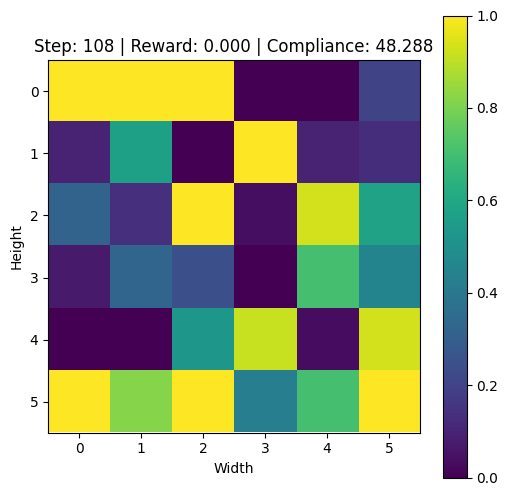


--- Beam Type 2 ---
  Total Reward: -22.6247
  Final Compliance: 21.2198
  Steps taken: 108


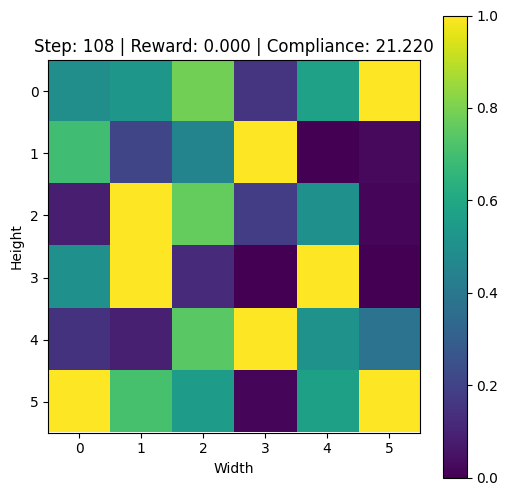


--- Beam Type 3 ---
  Total Reward: -24.1034
  Final Compliance: 41.9626
  Steps taken: 108


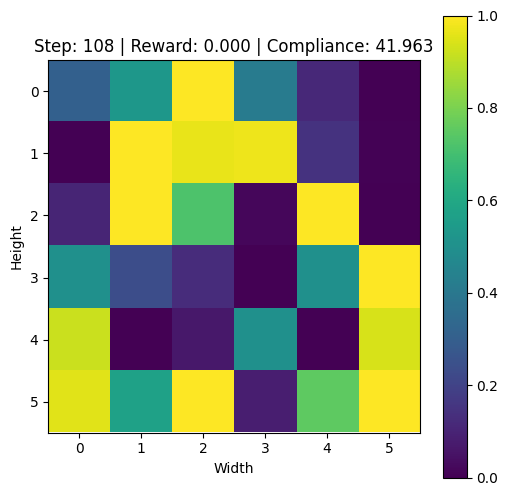


--- Beam Type 4 ---
  Total Reward: -14.7342
  Final Compliance: 20.1824
  Steps taken: 108


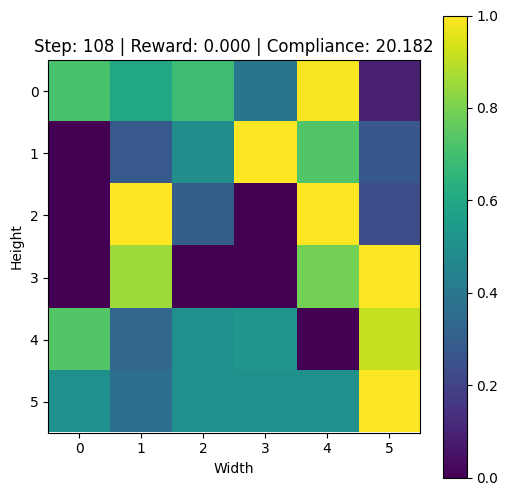


--- Beam Type 5 ---
  Total Reward: -17.9660
  Final Compliance: 47.7692
  Steps taken: 108


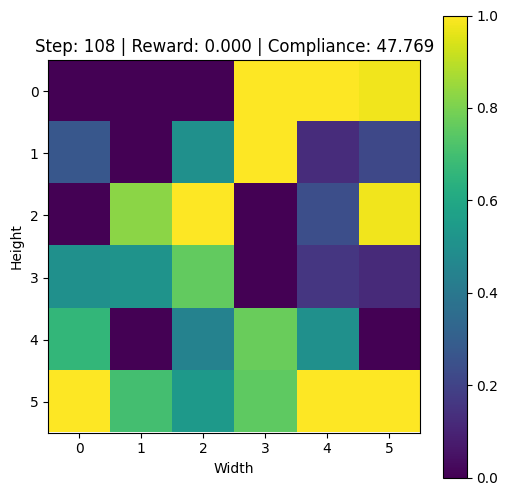


--- Beam Type 6 ---
  Total Reward: -19.7890
  Final Compliance: 45.6678
  Steps taken: 108


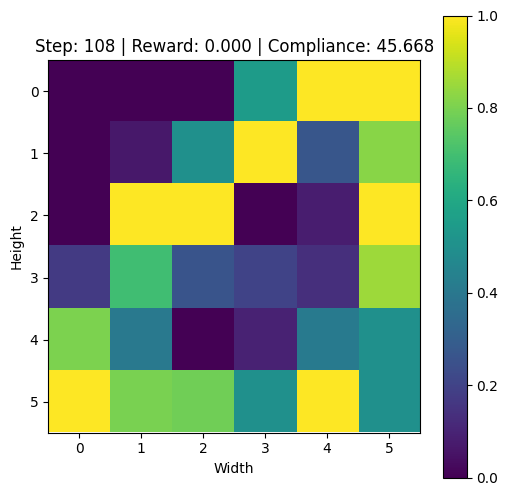


--- Beam Type 7 ---
  Total Reward: -12.2054
  Final Compliance: 31.9238
  Steps taken: 108


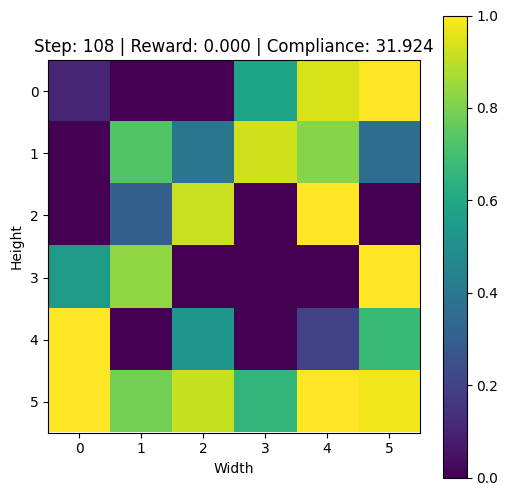


--- Beam Type 8 ---
  Total Reward: -14.9917
  Final Compliance: 37.1356
  Steps taken: 108


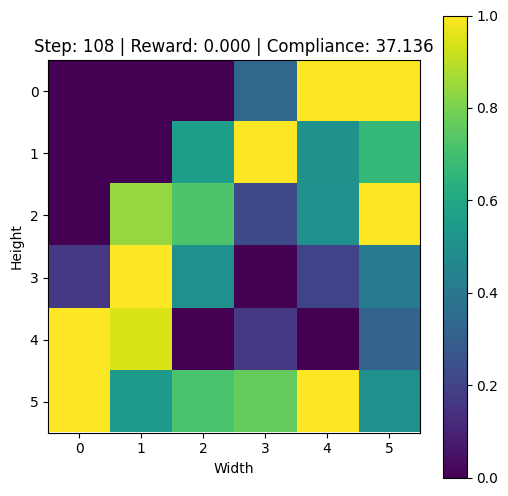


--- Beam Type 9 ---
  Total Reward: -27.9521
  Final Compliance: 50.8330
  Steps taken: 108


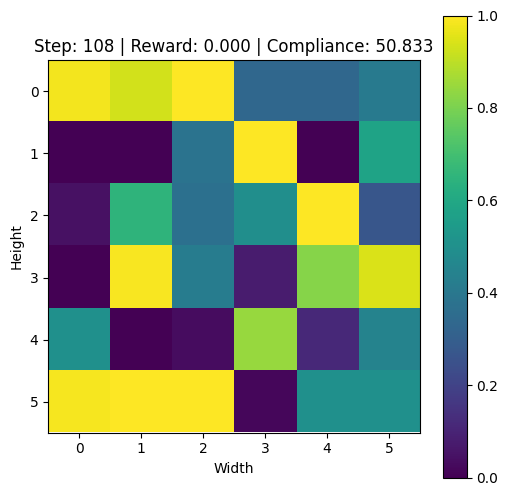


--------------------------------------------------------------------------------
RANDOM BEAMS (never seen exact config - TRUE generalization test)
--------------------------------------------------------------------------------

*** Random Beam Trial 1 ***
  Total Reward: -13.5986
  Final Compliance: 33.8563
  Steps taken: 108


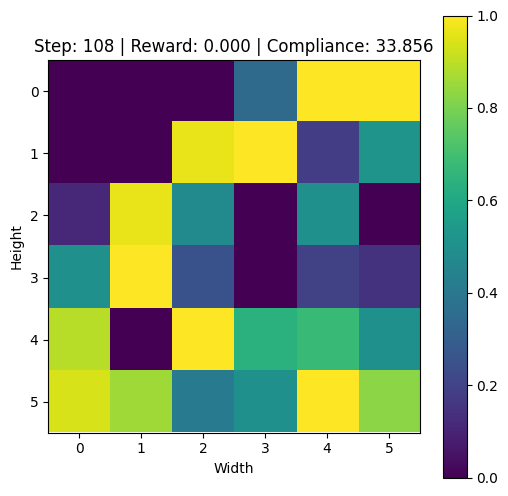


*** Random Beam Trial 2 ***
  Total Reward: -13.4437
  Final Compliance: 29.6353
  Steps taken: 108


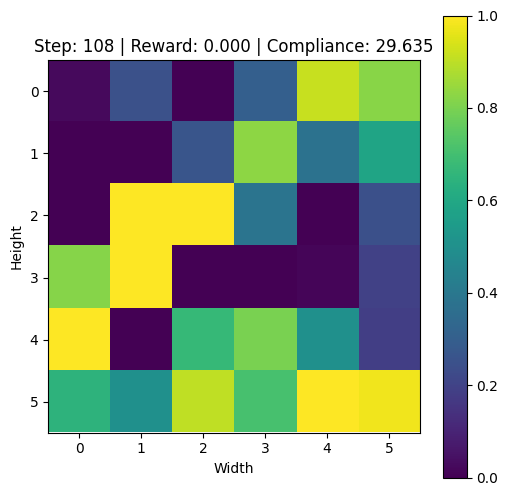


*** Random Beam Trial 3 ***
  Total Reward: -11.9789
  Final Compliance: 29.0138
  Steps taken: 108


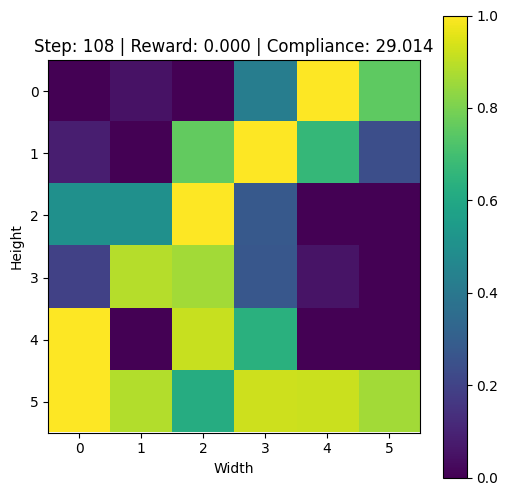


*** Random Beam Trial 4 ***
  Total Reward: -11.2106
  Final Compliance: 10.6294
  Steps taken: 108


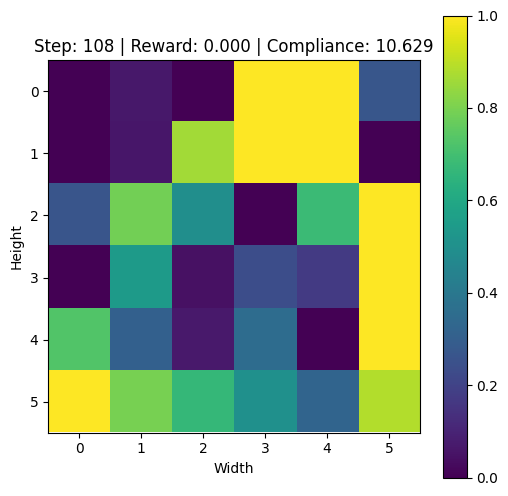


*** Random Beam Trial 5 ***
  Total Reward: -20.7745
  Final Compliance: 54.5746
  Steps taken: 108


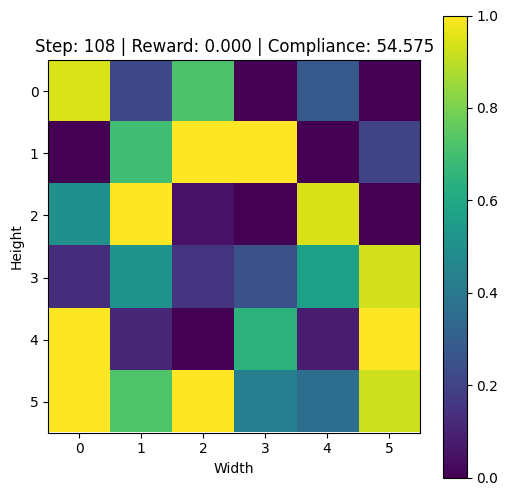


GENERALIZATION SUMMARY

Fixed beams (1-9):    Avg Reward = -18.7657, Avg Compliance = 38.3314
  Valid/Total: 9/9
Random beams:         Avg Reward = -14.2013, Avg Compliance = 31.5419
  Valid/Total: 5/5

----------------------------------------
Per-beam compliance breakdown:
----------------------------------------
  Beam 1: ✓ Compliance = 48.29
  Beam 2: ✓ Compliance = 21.22
  Beam 3: ✓ Compliance = 41.96
  Beam 4: ✓ Compliance = 20.18
  Beam 5: ✓ Compliance = 47.77
  Beam 6: ✓ Compliance = 45.67
  Beam 7: ✓ Compliance = 31.92
  Beam 8: ✓ Compliance = 37.14
  Beam 9: ✓ Compliance = 50.83

Evaluation complete!


In [ ]:
# ============ EVALUATION - Visualize optimized structure ============
print("\n" + "="*80)
print("EVALUATION: Running trained policy on test environments")
print("="*80)

def evaluate_beam_type(beam_type, label=""):
    """Evaluate policy on a single fixed beam type and render result."""
    eval_env = mbb_cnn.BeamOptimizationEnv(
        width=6, height=6, density=0.4, optimal_density=0.5, 
        reward_weights=None, beam_type=beam_type
    )
    
    state, _ = eval_env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
    
    ppo_agent.policy_old.eval()
    total_reward = 0
    
    for step in range(max_ep_len):
        with torch.no_grad():
            action, _, _ = ppo_agent.policy_old.act(state)
        
        action_int = action.cpu().numpy()[0]
        next_state, reward, done, _, info = eval_env.step(action_int)
        total_reward += reward
        
        state = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0).to(device)
        
        if done:
            break
    
    print(f"  Total Reward: {total_reward:.4f}")
    print(f"  Final Compliance: {eval_env.current_compliance:.4f}")
    print(f"  Steps taken: {step + 1}")
    
    eval_env.render()
    eval_env.close()
    
    return total_reward, eval_env.current_compliance

def evaluate_random_beam(trial_num):
    """Evaluate policy on a newly generated random beam."""
    eval_env = mbb_cnn.BeamOptimizationEnv(
        width=6, height=6, density=0.4, optimal_density=0.5, 
        reward_weights=None, use_random_beam=True
    )
    
    state, _ = eval_env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
    
    ppo_agent.policy_old.eval()
    total_reward = 0
    
    for step in range(max_ep_len):
        with torch.no_grad():
            action, _, _ = ppo_agent.policy_old.act(state)
        
        action_int = action.cpu().numpy()[0]
        next_state, reward, done, _, info = eval_env.step(action_int)
        total_reward += reward
        
        state = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0).to(device)
        
        if done:
            break
    
    print(f"  Total Reward: {total_reward:.4f}")
    print(f"  Final Compliance: {eval_env.current_compliance:.4f}")
    print(f"  Steps taken: {step + 1}")
    
    eval_env.render()
    eval_env.close()
    
    return total_reward, eval_env.current_compliance

# ============ TEST ON ALL FIXED BEAM TYPES ============
print("\n" + "-"*80)
print("FIXED BEAM TYPES (1-9) - Standard benchmark")
print("-"*80)

fixed_results = {}
for beam_type in EVAL_BEAM_TYPES:
    print(f"\n--- Beam Type {beam_type} ---")
    try:
        reward, compliance = evaluate_beam_type(beam_type)
        fixed_results[beam_type] = {'reward': reward, 'compliance': compliance}
    except Exception as e:
        print(f"  Error: {e}")
        fixed_results[beam_type] = {'reward': float('-inf'), 'compliance': float('inf')}

# ============ TEST ON RANDOM BEAMS (true generalization test) ============
print("\n" + "-"*80)
print("RANDOM BEAMS (never seen exact config - TRUE generalization test)")
print("-"*80)

random_results = {}
for trial in range(5):  # Test 5 random beam configurations
    print(f"\n*** Random Beam Trial {trial + 1} ***")
    try:
        reward, compliance = evaluate_random_beam(trial)
        random_results[trial] = {'reward': reward, 'compliance': compliance}
    except Exception as e:
        print(f"  Error: {e}")
        random_results[trial] = {'reward': float('-inf'), 'compliance': float('inf')}

# ============ SUMMARY ============
print("\n" + "="*80)
print("GENERALIZATION SUMMARY")
print("="*80)

# Filter out failed evaluations
valid_fixed = {k: v for k, v in fixed_results.items() if v['compliance'] < 1e8}
valid_random = {k: v for k, v in random_results.items() if v['compliance'] < 1e8}

if valid_fixed:
    fixed_avg_reward = np.mean([r['reward'] for r in valid_fixed.values()])
    fixed_avg_compliance = np.mean([r['compliance'] for r in valid_fixed.values()])
    print(f"\nFixed beams (1-9):    Avg Reward = {fixed_avg_reward:.4f}, Avg Compliance = {fixed_avg_compliance:.4f}")
    print(f"  Valid/Total: {len(valid_fixed)}/{len(fixed_results)}")
else:
    print("\nFixed beams: All failed!")

if valid_random:
    random_avg_reward = np.mean([r['reward'] for r in valid_random.values()])
    random_avg_compliance = np.mean([r['compliance'] for r in valid_random.values()])
    print(f"Random beams:         Avg Reward = {random_avg_reward:.4f}, Avg Compliance = {random_avg_compliance:.4f}")
    print(f"  Valid/Total: {len(valid_random)}/{len(random_results)}")
else:
    print("Random beams: All failed!")

# Per-beam breakdown
print("\n" + "-"*40)
print("Per-beam compliance breakdown:")
print("-"*40)
for beam_type, result in sorted(fixed_results.items()):
    status = "✓" if result['compliance'] < 100 else ("⚠" if result['compliance'] < 1000 else "✗")
    print(f"  Beam {beam_type}: {status} Compliance = {result['compliance']:.2f}")

ppo_agent.policy_old.train()
print("\n" + "="*80)
print("Evaluation complete!")
print("="*80)